In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
lung_xray = files.upload()

Saving lung-xray.png to lung-xray.png


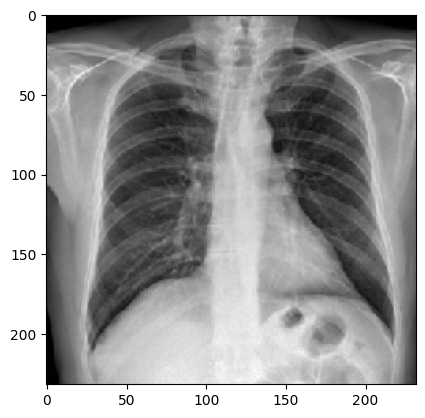

In [3]:
image = list(lung_xray.keys())[0]
lung_image = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
plt.imshow(lung_image, cmap="gray")
plt.show()

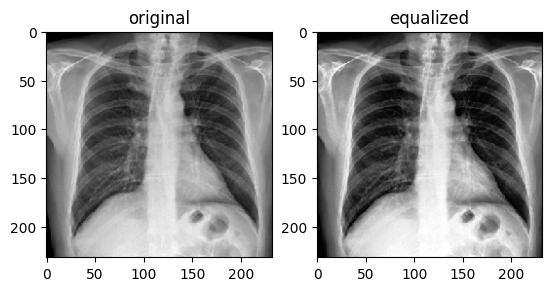

True

In [4]:
equalized = cv2.equalizeHist(lung_image)
plt.subplot(1,2,1)
plt.imshow(lung_image, cmap="gray")
plt.title("original")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap="gray")
plt.title("equalized")
plt.show()

from pathlib import Path
DIR_OUTPUT = Path("./output")
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)
cv2.imwrite(DIR_OUTPUT / "equalized.png", equalized)

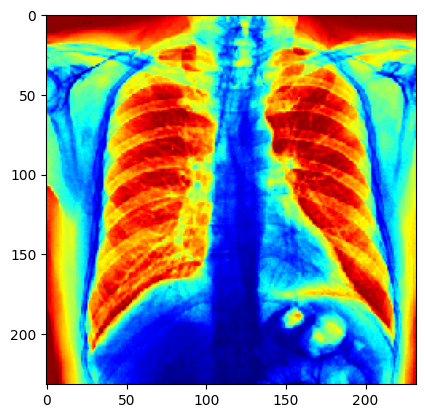

True

In [5]:
falsecolor_heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
plt.imshow(falsecolor_heatmap)
plt.show()
cv2.imwrite(DIR_OUTPUT / "falsecolor_heatmap.png", falsecolor_heatmap)

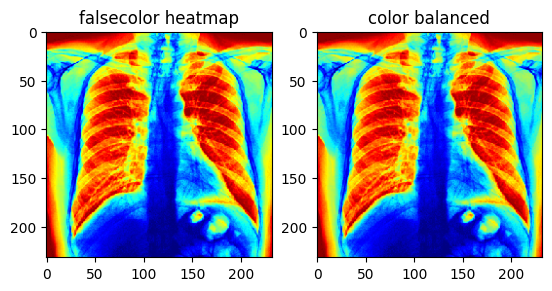

True

In [6]:
img = falsecolor_heatmap.astype(np.float32)
avg_b, avg_g, avg_r = np.mean(img, axis=(0, 1))
avg_gray = (avg_b+avg_g+avg_r)/3
img[:, :, 0] *= avg_gray / (avg_b + 1e-6)
img[:, :, 1] *= avg_gray / (avg_g + 1e-6)
img[:, :, 2] *= avg_gray / (avg_r + 1e-6)
balanced = np.clip(img, 0, 255).astype(np.uint8)

plt.subplot(1,2,1)
plt.imshow(falsecolor_heatmap)
plt.title("falsecolor heatmap")

plt.subplot(1,2,2)
plt.imshow(balanced)
plt.title("color balanced")
plt.show()

from pathlib import Path
DIR_OUTPUT = Path("./output")
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)
cv2.imwrite(DIR_OUTPUT / "balanced.png", balanced)

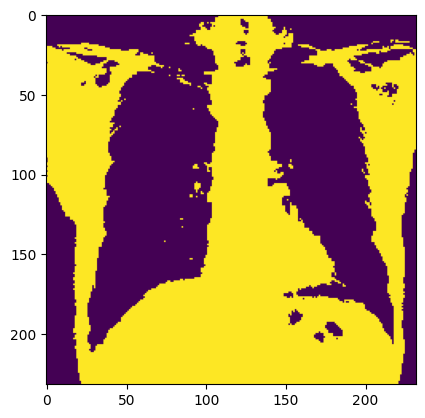

True

In [7]:
T = 101
_, thresh = cv2.threshold(lung_image, T, 255, cv2.THRESH_BINARY)
plt.imshow(thresh)
plt.show()

cv2.imwrite(DIR_OUTPUT / "thresh.png", thresh)

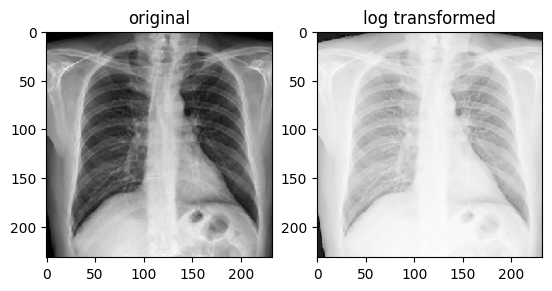

True

In [9]:
img = lung_image.astype(np.float32)
#log transformation
c = 255 / np.log(1+np.max(img))
log_transformed = c * np.log(1+img)
log_transformed = np.uint8(log_transformed)

plt.subplot(1,2,1)
plt.imshow(lung_image, cmap="gray")
plt.title("original")

plt.subplot(1,2,2)
plt.imshow(log_transformed, cmap="gray")
plt.title("log transformed")
plt.show()

cv2.imwrite(DIR_OUTPUT / "log_transformed.png", log_transformed)

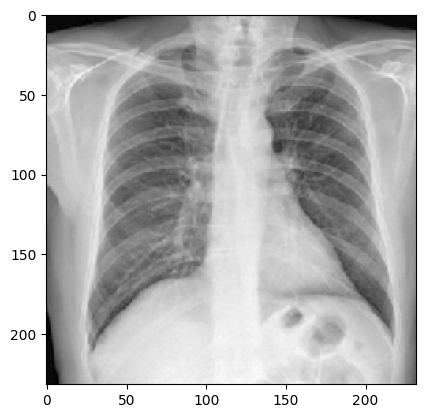

True

In [11]:
def gamma_transform(img, gamma):
    # Build a table mapping every possible value 0-255 to its new value
    lut = np.array([255 * (i / 255) ** gamma for i in range(256)])
    lut = np.clip(lut, 0, 255).astype('uint8')
    return cv2.LUT(img, lut)

gamma_img = gamma_transform(lung_image, 0.6)
plt.imshow(gamma_img, cmap="gray")
plt.show()

cv2.imwrite(DIR_OUTPUT / 'gamma.png', gamma_img)

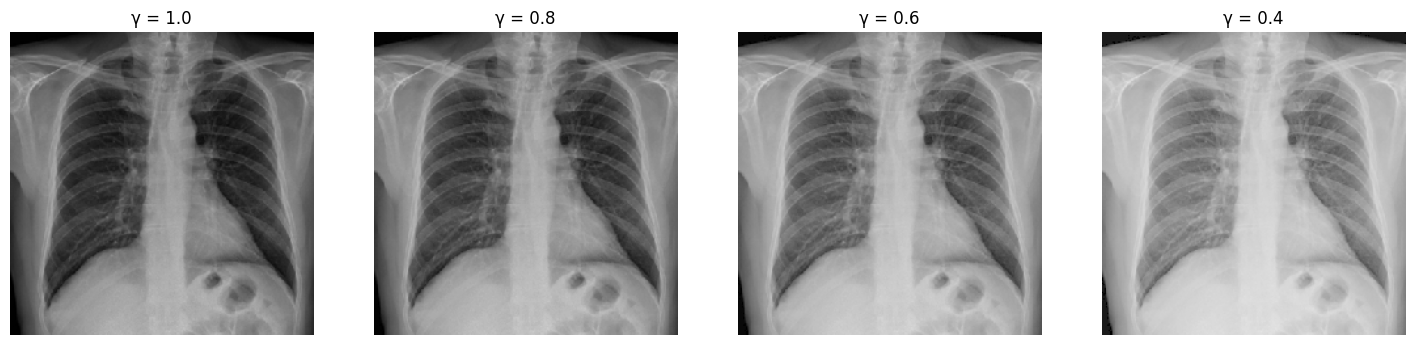

In [12]:
gammas = [1.0, 0.8, 0.6, 0.4]
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for a, g in zip(ax, gammas):
    a.imshow(gamma_transform(lung_image, g), cmap='gray', vmin=0, vmax=255)
    a.set_title(f'γ = {g}')
    a.axis('off')
plt.show()